# Fractional Abundances

Here we compute the fractional abundances for Neon ions, assuming the coronal equilibrium model.
Let us plot the fractional abundances varying with the temperature for a fixed electron density.


In [1]:
import numpy as np
import ultraplot as uplt

from cherab.core.atomic.elements import neon
from cherab.imas.ids.common import solve_coronal_equilibrium
from cherab.openadas import OpenADAS
from cherab.openadas.install import install_adf11acd, install_adf11scd

Download the necessary atomic data from OpenADAS if not already available.


In [2]:
atomic_data = OpenADAS(permit_extrapolation=True, missing_rates_return_null=False)
try:
    atomic_data.ionisation_rate(neon, 1)
except RuntimeError:
    install_adf11acd(neon, "adf11/acd96/acd96_ne.dat", download=True)
    install_adf11scd(neon, "adf11/scd96/scd96_ne.dat", download=True)

Installing adf11/acd96/acd96_ne.dat...
 - downloading ADF file 'adf11/acd96/acd96_ne.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/acd96/acd96_ne.dat'


Installing adf11/scd96/scd96_ne.dat...
 - downloading ADF file 'adf11/scd96/scd96_ne.dat' to '/home/runner/.cherab/openadas/repository/_download_cache/adf11/scd96/scd96_ne.dat'


Set the electron density and the range of electron temperatures.


In [3]:
ELECTRON_DENSITY = 1e19
electron_temperatures = np.logspace(-0.2, 3.2, 100)

In [4]:
abundances = solve_coronal_equilibrium(
    neon,
    np.ones_like(electron_temperatures),
    np.full_like(electron_temperatures, ELECTRON_DENSITY),
    electron_temperatures,
    atomic_data=atomic_data,
)

Plot the fractional abundances as a function of the electron temperature.


/home/runner/work/imas/imas/.pixi/envs/docs/lib/python3.14/site-packages/ultraplot/__init__.py:221: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


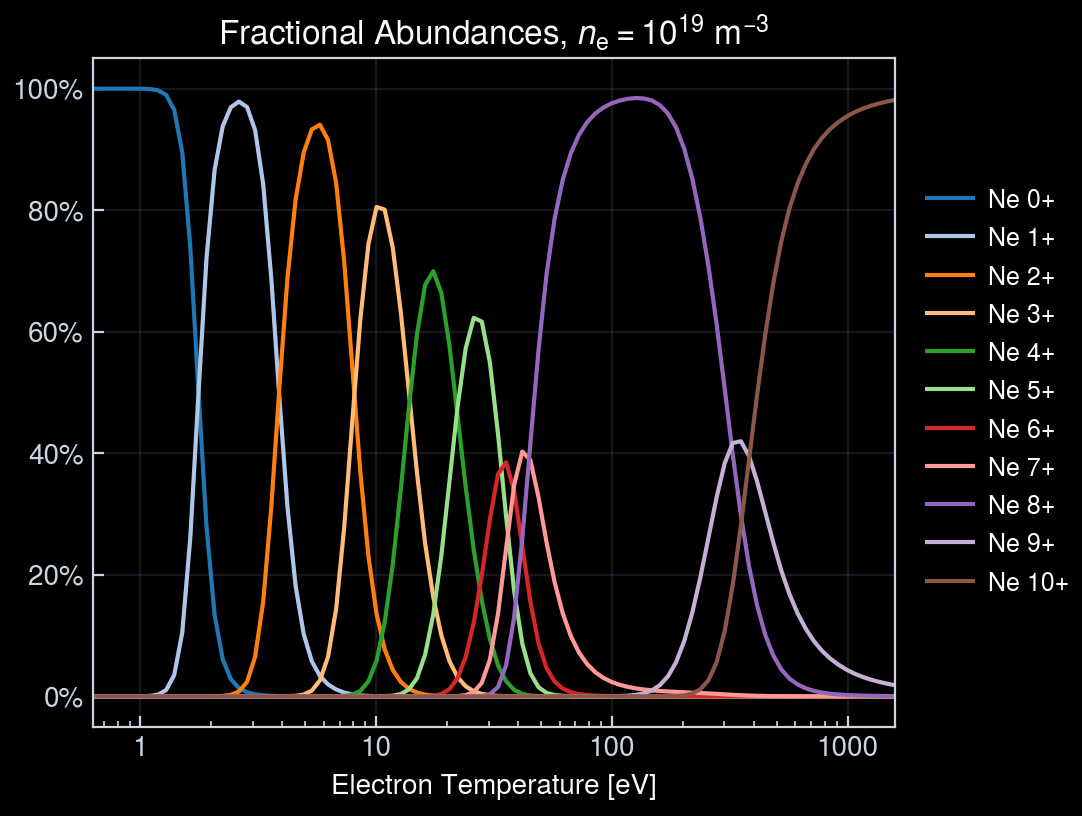

In [5]:
fig, ax = uplt.subplots(refaspect=1.2, refwidth=4)
lines = ax.plot(
    electron_temperatures,
    abundances.T,
    cycle="tab20",
)
ax.legend(
    lines,
    [f"Ne {i}+" for i in range(neon.atomic_number + 1)],
    ncols=1,
    loc="right",
    frame=False,
    fontcolor="w",
)
ax.format(
    style="dark_background",
    xscale="log",
    yformatter=("percent", 1),
    tickminor=True,
    tickdir="in",
    grid=True,
    gridalpha=0.3,
    xlabel="Electron Temperature [eV]",
    title=r"Fractional Abundances, $n_\mathrm{e} = 10^{19}$ m$^{-3}$",
)